In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file
# Assuming the file is named 'clusters.csv' and has no header row

df = pd.read_csv('newtest/ssdeep/cluster_results_merged_csv_threshold_50_20250325_033018.csv',)

# # Count occurrences of each cluster label to get cluster sizes
# cluster_sizes = df['Cluster_Label'].value_counts()


In [8]:
def get_files_by_all_clusters(df):
    """
    Get all file paths organized by their cluster labels.
    
    Parameters:
    df (pd.DataFrame): DataFrame containing File_Path and Cluster_Label columns
    
    Returns:
    dict: Dictionary where keys are cluster labels and values are lists of file paths
    """
    # Group by Cluster_Label and convert to dictionary
    cluster_files_dict = df.groupby('Cluster_Label')['File_Path'].apply(list).to_dict()
    return cluster_files_dict

In [11]:
# Get files from all clusters
all_cluster_files = get_files_by_all_clusters(df)

# Print results
for cluster, files in all_cluster_files.items():
    print(f"Cluster {cluster}: {files}")
    files

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [10]:
all_cluster_files

{0: ['/usr/src/app/datacopy/evasive-it/2021/a470823db33706bd6ea4768a5240e82815fac99ce26dbdfa4709843c770e8d3e',
  '/usr/src/app/datacopy/evasive-it/2021/07a8958e9a5969c1643093bc114def0d985685e7b34eba196cf93572217385ae'],
 1: ['/usr/src/app/datacopy/evasive-it/2021/55a3c455cfbd70fd91663e251ea65db6452edbb0d730c8e3a48b18a4b3f8df6a',
  '/usr/src/app/datacopy/evasive-it/2021/b9c705cedc02d6ef6ea1764f6dfb0724ce66c878f5c033d5187b9b877fc926e1',
  '/usr/src/app/datacopy/evasive-it/2022/Trojan.Win32.Bublik.aeld-736c814b6d4979459e0e30e6c460e57902fa98f0f784afdfcccdf000e69c01f1',
  '/usr/src/app/datacopy/UCSB.JP/data_feed.geo_japan_6m_public_flag/f/c/b/fcb53d9a6cd9b4e63c21e5a9a32201bf36bdbcc2.bin',
  '/usr/src/app/datacopy/CodexGiga/b9ca6f8b25ffd8fa66194fc826037d667039e830.codex'],
 2: ['/usr/src/app/datacopy/evasive-it/2021/ddfcd8635271a01c98d29fce4c227a87d093647d47f95ee9a7566805780074ef',
  '/usr/src/app/datacopy/evasive-it/2019/79e5a8321916d4e30adeadbb4a8c90332b3795a745fbc4e2befe772807ce7dd0'],
 3

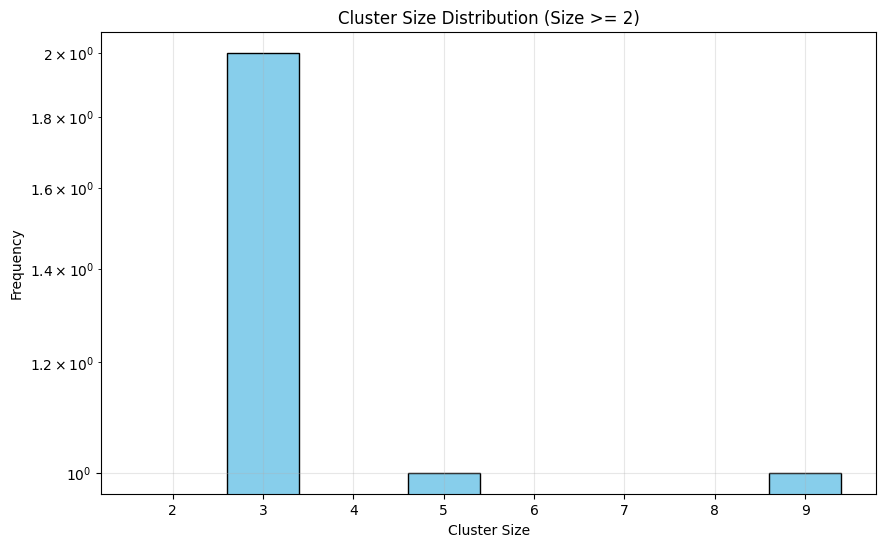

In [26]:

df['Cluster_Label'] = pd.to_numeric(df['Cluster_Label'], errors='coerce')

# Get labels, dropping any NaN
labels = df['Cluster_Label'].dropna().astype(int).tolist()  # Ensure integers

# Calculate cluster sizes (how many times each label appears)
cluster_sizes = {label: labels.count(label) for label in set(labels) if label >= 0}

# Filter for clusters with size >= 2
filtered_sizes = [size for size in cluster_sizes.values() if size >= 2]

# Check if there’s anything to plot
if not filtered_sizes:
    print("No clusters with size >= 2 found.")
else:
    # Plot histogram
    plt.figure(figsize=(10, 6))
    plt.hist(filtered_sizes, bins=range(2, max(filtered_sizes) + 2), 
             align='left', rwidth=0.8, color='skyblue', edgecolor='black')
    plt.yscale('log')  # Log scale as requested earlier
    plt.xticks(range(2, max(filtered_sizes) + 1))  # Ensure integer x-axis
    plt.xlabel("Cluster Size")
    plt.ylabel("Frequency")
    plt.title("Cluster Size Distribution (Size >= 2)")
    plt.grid(True, alpha=0.3)
    plt.show()